In [15]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import pandas as pd

data_part1 = r"D:\seg_clust_5761"
data_part2 = r"D:\seg_clust_7018"
save_path = r"C:\Users\Lindholm\Dropbox\BSc\report_figures"

In [2]:
BASE_DIR = Path(data_part1)
def pc_sort_key(d: Path) -> int:
    """Extract the PC number from a directory name like 'pc_01'."""
    return int(d.name.split("_")[1])

# Find all pc_* directories.
pc_dirs = sorted(
    (d for d in BASE_DIR.iterdir() if d.is_dir() and d.name.startswith("pc_")),
    key=pc_sort_key
)
print("PC dirs found:", [d.name for d in pc_dirs])
pc_dirs_part1 = pc_dirs[:7]

PC dirs found: ['pc_032', 'pc_064', 'pc_128', 'pc_256', 'pc_512', 'pc_1024', 'pc_2048', 'pc_4096']


In [3]:
BASE_DIR = Path(data_part2)
def pc_sort_key(d: Path) -> int:
    """Extract the PC number from a directory name like 'pc_01'."""
    return int(d.name.split("_")[1])

# Find all pc_* directories.
pc_dirs = sorted(
    (d for d in BASE_DIR.iterdir() if d.is_dir() and d.name.startswith("pc_")),
    key=pc_sort_key
)
print("PC dirs found:", [d.name for d in pc_dirs])
pc_dirs_part2 = pc_dirs

pc_dirs_combined = pc_dirs_part1 + pc_dirs_part2

PC dirs found: ['pc_4096', 'pc_6144', 'pc_8192']


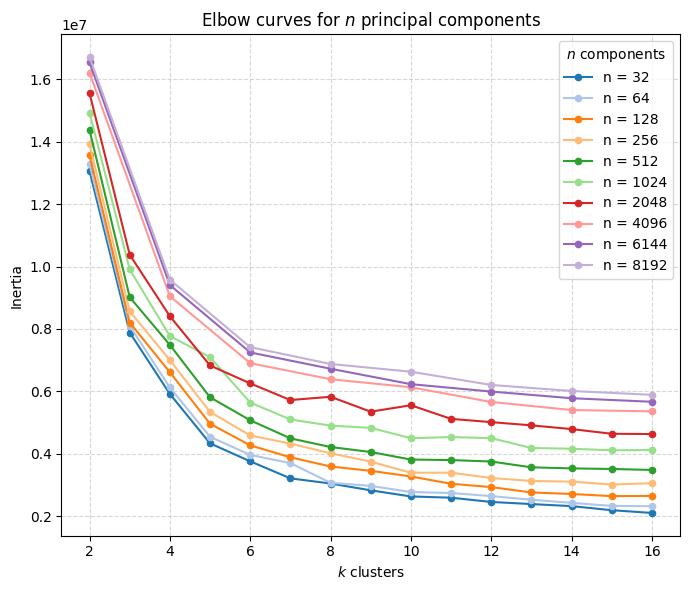

In [16]:
plt.figure(figsize=(7, 6))
cmap = plt.get_cmap("tab20")
colors = cmap(np.arange(len(pc_dirs_combined)) % cmap.N)

start_idx = 0
end_idx = 16
for i, (pc_dir, color) in enumerate(zip(pc_dirs_combined, colors)):
    if i >= len(pc_dirs_part1):
        end_idx = 8
    summary_path = pc_dir / "kmeans_summary.npz"
    data = np.load(summary_path)
    k_values = data["k_values"][start_idx:end_idx]
    inertias = data["inertias"][start_idx:end_idx]

    plt.plot(k_values, inertias, marker="o", markersize=4.5, color=color
        , label="n = " + (str(pc_dir.name).split("_")[1].removeprefix("0")))

plt.xlabel("$k$ clusters")
plt.ylabel("Inertia")
plt.title("Elbow curves for $n$ principal components")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="$n$ components", loc="upper right")
plt.tight_layout()
plt.savefig(Path(save_path) / "elbow_curves.png", dpi=300)
plt.show()

PC dirs found: ['pc_002', 'pc_003', 'pc_004', 'pc_005', 'pc_006', 'pc_007', 'pc_008', 'pc_016', 'pc_032', 'pc_064', 'pc_128', 'pc_256']


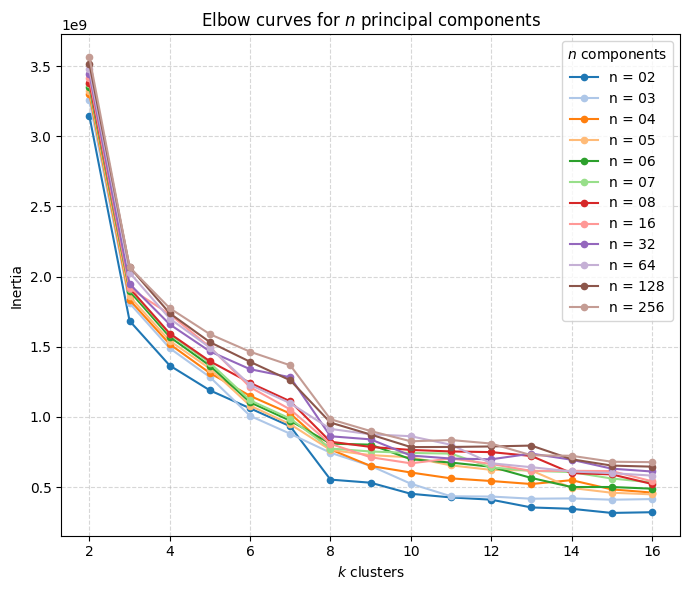

In [17]:
data_part3 = r"D:\seg_clust_1733"
BASE_DIR = Path(data_part3)
def pc_sort_key(d: Path) -> int:
    return int(d.name.split("_")[1])
# Find all pc_* directories.
pc_dirs = sorted(
    [d for d in BASE_DIR.iterdir() if d.is_dir() and d.name.startswith("pc_")],
    key=pc_sort_key
)
print("PC dirs found:", [d.name for d in pc_dirs])
pc_dirs_part3 = pc_dirs

fig, ax = plt.subplots(figsize=(7, 6))
cmap = plt.get_cmap("tab20")
colors = cmap(np.arange(len(pc_dirs_part3)) % cmap.N)
start_idx = 0
end_idx = 16
for i, (pc_dir, color) in enumerate(zip(pc_dirs_part3, colors)):
    summary_path = pc_dir / "kmeans_summary.npz"
    data = np.load(summary_path)

    k_values = data["k_values"][start_idx:end_idx]
    inertias = data["inertias"][start_idx:end_idx]

    plt.plot(k_values, inertias, marker="o", markersize=4.5, color=color
        , label="n = " + (str(pc_dir.name).split("_")[1].removeprefix("0")))

plt.xlabel("$k$ clusters")
plt.ylabel("Inertia")
plt.title("Elbow curves for $n$ principal components")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="$n$ components", loc="upper right")
plt.tight_layout()
plt.savefig(Path(save_path) / "elbow_curves.png", dpi=300)
plt.show()


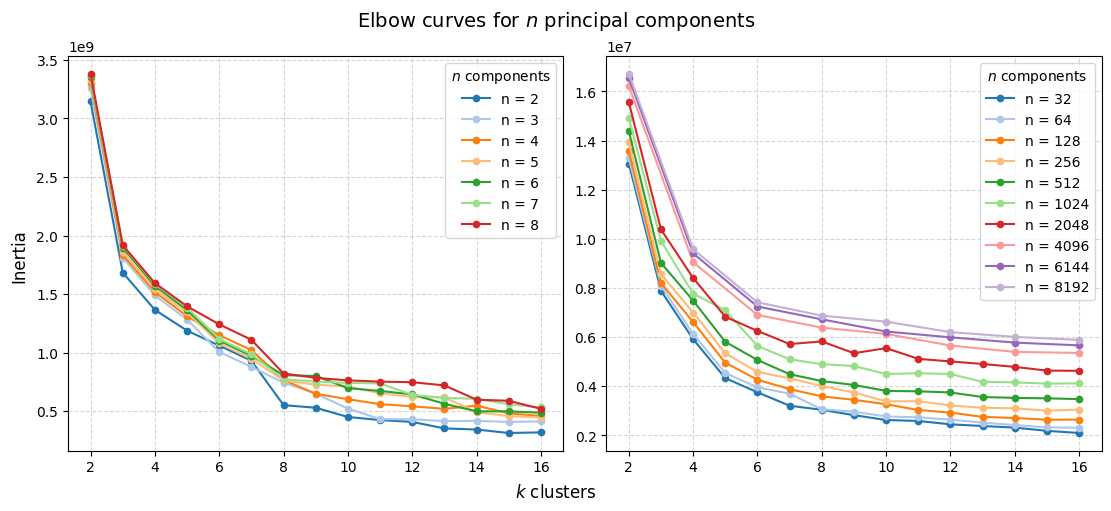

In [33]:
# 2 Figures combined.
fig, ax = plt.subplots(1, 2, figsize=(11, 5), constrained_layout=True)
cmap = plt.get_cmap("tab20")
colors = cmap(np.arange(50) % cmap.N)
start_idx = 0
end_idx = 16
for i, (pc_dir, color) in enumerate(zip(pc_dirs_combined, colors)):
    if i >= len(pc_dirs_part1):
        end_idx = 8
    summary_path = pc_dir / "kmeans_summary.npz"
    data = np.load(summary_path)
    k_values = data["k_values"][start_idx:end_idx]
    inertias = data["inertias"][start_idx:end_idx]
    ax[1].plot(k_values, inertias, marker="o", markersize=4.5, color=color
        , label="n = " + (str(pc_dir.name).split("_")[1].removeprefix("0")))
for i, (pc_dir, color) in enumerate(zip(pc_dirs_part3[0:7], colors)):
    summary_path = pc_dir / "kmeans_summary.npz"
    data = np.load(summary_path)
    k_values = data["k_values"]
    inertias = data["inertias"]
    ax[0].plot(k_values, inertias, marker="o", markersize=4.5, color=color
        , label="n = " + (str(pc_dir.name).split("_")[1].removeprefix("0").removeprefix("0")))
ax[0].grid(True, linestyle="--", alpha=0.5)
ax[0].legend(title="$n$ components", loc="upper right")
ax[1].grid(True, linestyle="--", alpha=0.5)
ax[1].legend(title="$n$ components", loc="upper right")
fig.suptitle("Elbow curves for $n$ principal components", fontsize=14)
fig.supxlabel("$k$ clusters", fontsize=12)
fig.supylabel("Inertia", fontsize=12)
plt.savefig(Path(save_path) / "elbow_curves_combined.png", dpi=300)
plt.show()